# DreamerV3 — Visual Experiments

> **Goal:** Understand the scale-invariance tricks that let one fixed configuration of Dreamer master 150+ domains.

## What we'll explore

| # | Experiment | Question answered |
|---|---|---|
| 1 | **Symlog** | How does symlog tame signals spanning many orders of magnitude? |
| 2 | **Two-hot value** | How does two-hot + cross-entropy give scale-robust, distributional value learning? |
| 3 | **Free bits** | How does a KL floor stop the model over-regularizing on easy domains? |
| 4 | **Return normalization** | How does percentile scaling make one entropy coefficient work across reward scales? |

---
**Linked theory:** [research/03-dreamerv3.md](../research/03-dreamerv3.md)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.rcParams.update({
    'figure.dpi': 110,
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.alpha': 0.35,
})


def symlog(x):
    return np.sign(x) * np.log1p(np.abs(x))


def symexp(y):
    return np.sign(y) * np.expm1(np.abs(y))


print('Setup complete.')

Setup complete.


---
## Experiment 1: Symlog

**Question:** Rewards and values across domains span tiny to huge magnitudes. How does symlog $=\mathrm{sign}(x)\ln(1+|x|)$ compress them while staying well-behaved near zero?

We plot the transform and show that targets spanning $[-1, 10^4]$ become a compact, balanced range in symlog space — so one learning rate fits all.

In [2]:
x = np.linspace(-1000, 1000, 2000)
# targets with a huge dynamic range (mix of small and large rewards)
targets = np.concatenate([np.random.uniform(-1, 1, 400),
                          np.random.uniform(50, 200, 200),
                          np.random.uniform(2000, 10000, 100)])
print(f'raw targets range: [{targets.min():.1f}, {targets.max():.1f}]')
print(f'symlog range:      [{symlog(targets).min():.2f}, {symlog(targets).max():.2f}]')
print(f'roundtrip max err: {np.abs(symexp(symlog(targets)) - targets).max():.2e}')

raw targets range: [-1.0, 9892.1]
symlog range:      [-0.69, 9.20]
roundtrip max err: 7.28e-12


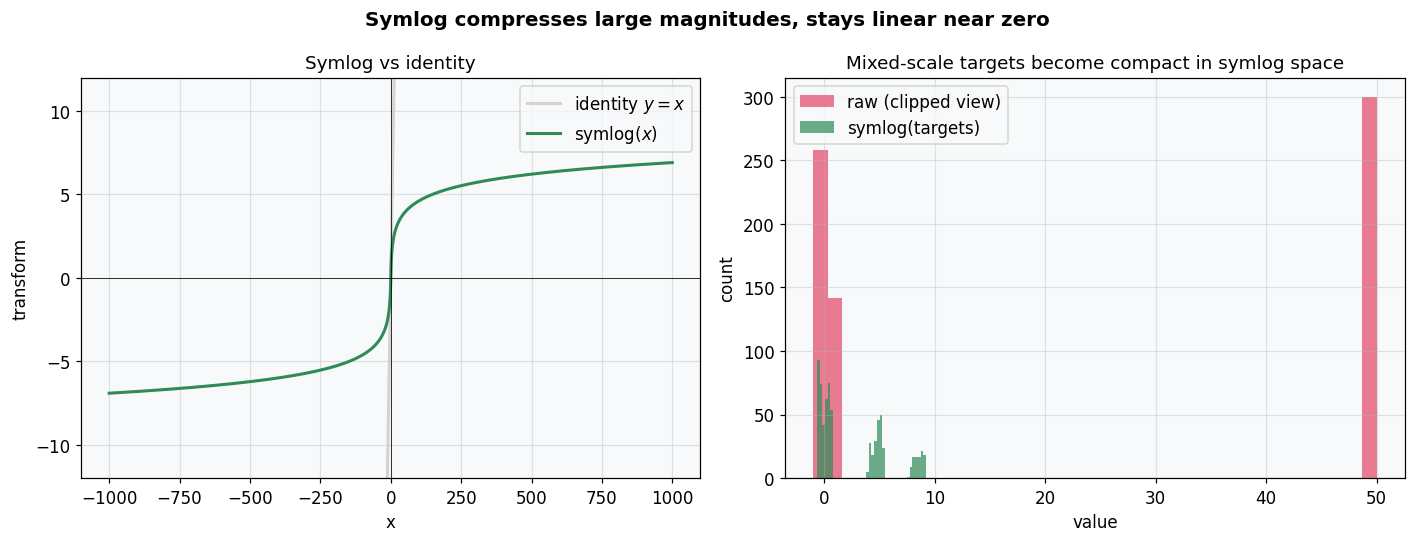

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Symlog compresses large magnitudes, stays linear near zero', fontsize=13, fontweight='bold')

ax = axes[0]
ax.plot(x, x, color='lightgray', lw=2, label='identity $y=x$')
ax.plot(x, symlog(x), color='seagreen', lw=2, label='symlog$(x)$')
ax.set_ylim(-12, 12)
ax.set_xlabel('x'); ax.set_ylabel('transform')
ax.set_title('Symlog vs identity')
ax.legend()
ax.axhline(0, color='k', lw=0.5); ax.axvline(0, color='k', lw=0.5)

ax2 = axes[1]
ax2.hist(np.clip(targets, -50, 50), bins=40, alpha=0.55, color='crimson', label='raw (clipped view)')
ax2.hist(symlog(targets), bins=40, alpha=0.7, color='seagreen', label='symlog(targets)')
ax2.set_xlabel('value'); ax2.set_ylabel('count')
ax2.set_title('Mixed-scale targets become compact in symlog space')
ax2.legend()

plt.tight_layout()
plt.show()

### What you see

1. **What the plot shows:** The left panel shows symlog hugging the identity line near the origin then bending to grow only logarithmically for large $|x|$. The right histogram shows targets that span $[-1, 10^4]$ collapsing into a tight band roughly $[-9, 9]$ in symlog space.
2. **Why it looks this way:** $\ln(1+|x|)$ is ≈$x$ for small $x$ (so small rewards keep their resolution) but grows slowly for large $x$ (so huge rewards do not dominate). It is invertible via symexp, so no information is lost.
3. **Key takeaway:** Predicting in symlog space means one fixed learning rate handles both $\pm1$ and $\pm10^4$ rewards — a cornerstone of DreamerV3's domain-agnostic configuration.

---
## Experiment 2: Two-hot value

**Question:** Instead of MSE regression, DreamerV3 discretizes the value axis into bins and predicts a distribution via two-hot targets. What does that buy?

We show how a scalar becomes a two-hot target whose expectation is exact, and how a categorical value head represents a *multimodal* value that MSE would average into a meaningless middle.

In [4]:
bins = np.linspace(-5, 5, 21)


def two_hot(v, bins):
    v = np.clip(v, bins[0], bins[-1])
    k = np.searchsorted(bins, v) - 1
    k = np.clip(k, 0, len(bins) - 2)
    lo, hi = bins[k], bins[k + 1]
    w = (v - lo) / (hi - lo)
    out = np.zeros(len(bins))
    out[k] = 1 - w; out[k + 1] = w
    return out


v = 1.7
th = two_hot(v, bins)
print(f'value {v} -> two-hot expectation {np.dot(th, bins):.3f}')

# a bimodal value target (two equally likely returns): -3 and +3
dist = 0.5 * two_hot(-3.0, bins) + 0.5 * two_hot(3.0, bins)
mse_point = np.dot(dist, bins)   # what an MSE head would output: the mean
print(f'bimodal target mean (MSE head) = {mse_point:.2f}  (a value that never occurs)')

value 1.7 -> two-hot expectation 1.700
bimodal target mean (MSE head) = 0.00  (a value that never occurs)


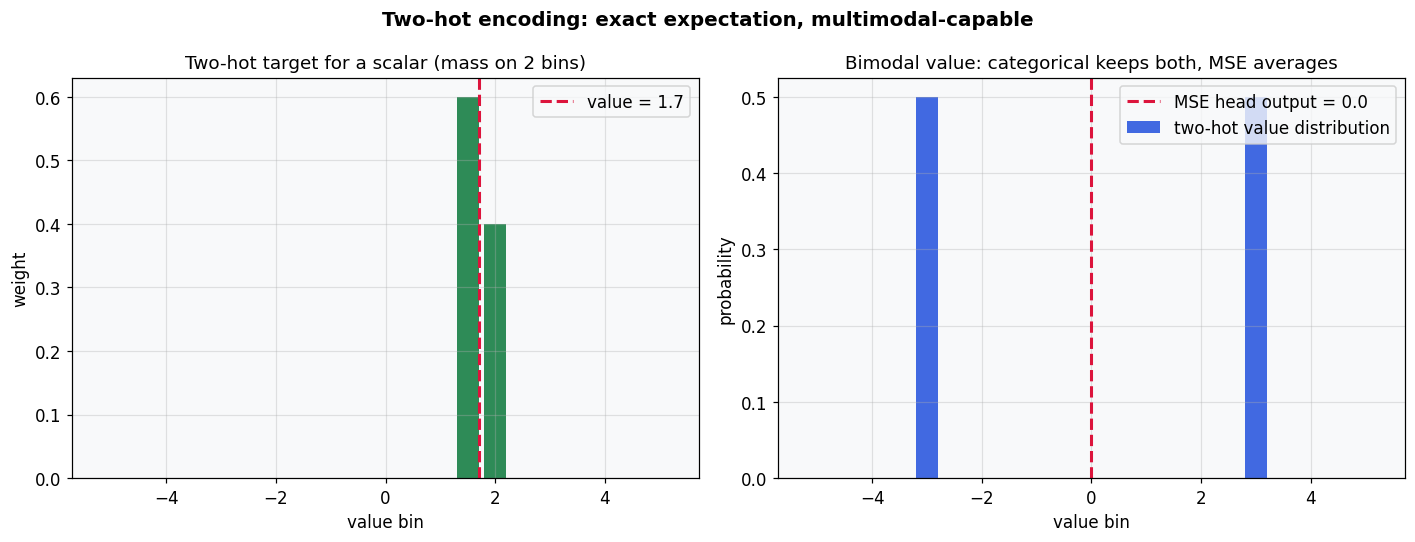

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Two-hot encoding: exact expectation, multimodal-capable', fontsize=13, fontweight='bold')

axes[0].bar(bins, th, width=0.4, color='seagreen')
axes[0].axvline(v, color='crimson', ls='--', lw=2, label=f'value = {v}')
axes[0].set_xlabel('value bin'); axes[0].set_ylabel('weight')
axes[0].set_title('Two-hot target for a scalar (mass on 2 bins)')
axes[0].legend()

axes[1].bar(bins, dist, width=0.4, color='royalblue', label='two-hot value distribution')
axes[1].axvline(mse_point, color='crimson', ls='--', lw=2, label=f'MSE head output = {mse_point:.1f}')
axes[1].set_xlabel('value bin'); axes[1].set_ylabel('probability')
axes[1].set_title('Bimodal value: categorical keeps both, MSE averages')
axes[1].legend()

plt.tight_layout()
plt.show()

### What you see

1. **What the plot shows:** The left panel puts weight on the two bins straddling 1.7, with weights chosen so the expectation is exactly 1.7. The right panel shows a value that is equally likely to be −3 or +3; the categorical head keeps both peaks, while an MSE head would output their mean (≈0), a value that never happens.
2. **Why it looks this way:** Two-hot turns regression into classification over fixed bins, trained with cross-entropy — robust to target scale and able to represent a full distribution rather than a single mean.
3. **Key takeaway:** Discrete two-hot value learning is both scale-stable (cross-entropy, not MSE) and distributional, helping DreamerV3 learn values reliably across wildly different domains.

---
## Experiment 3: Free bits

**Question:** On easy domains the model can over-regularize — driving the KL to zero and throwing away the posterior's information. How do free bits prevent that?

Free bits clip the effective KL loss at a floor: once the KL is below the threshold, there is no gradient pushing it lower. We plot the effective loss against the raw KL.

In [6]:
raw_kl = np.linspace(0, 5, 400)
free_bits = 1.0
loss_plain = raw_kl                       # standard: always penalize
loss_freebits = np.maximum(raw_kl, free_bits)   # clipped at the floor: flat below threshold
# gradient magnitude that actually pushes KL down (1 above threshold, 0 below)
grad_freebits = (raw_kl > free_bits).astype(float)
print(f'free-bits threshold = {free_bits} nat; below it the KL gets no downward gradient')

free-bits threshold = 1.0 nat; below it the KL gets no downward gradient


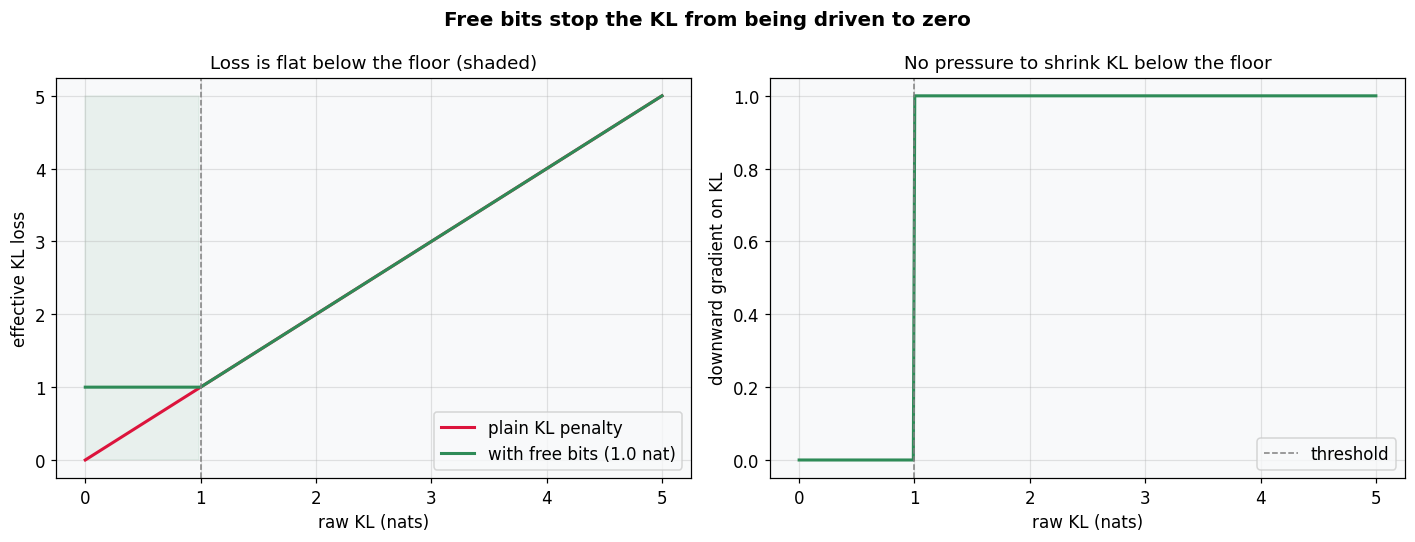

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Free bits stop the KL from being driven to zero', fontsize=13, fontweight='bold')

ax = axes[0]
ax.plot(raw_kl, loss_plain, color='crimson', lw=2, label='plain KL penalty')
ax.plot(raw_kl, loss_freebits, color='seagreen', lw=2, label=f'with free bits ({free_bits} nat)')
ax.axvline(free_bits, color='gray', ls='--', lw=1)
ax.fill_between(raw_kl, 0, loss_freebits.max(), where=raw_kl < free_bits, color='seagreen', alpha=0.08)
ax.set_xlabel('raw KL (nats)'); ax.set_ylabel('effective KL loss')
ax.set_title('Loss is flat below the floor (shaded)')
ax.legend()

ax2 = axes[1]
ax2.plot(raw_kl, grad_freebits, color='seagreen', lw=2)
ax2.axvline(free_bits, color='gray', ls='--', lw=1, label='threshold')
ax2.set_xlabel('raw KL (nats)'); ax2.set_ylabel('downward gradient on KL')
ax2.set_title('No pressure to shrink KL below the floor')
ax2.legend()

plt.tight_layout()
plt.show()

### What you see

1. **What the plot shows:** The plain penalty (red) keeps falling all the way to zero KL, while the free-bits loss (green) is flat in the shaded region below the 1-nat floor. The right panel shows the downward gradient is exactly zero there.
2. **Why it looks this way:** Clipping the loss at a floor removes the incentive to compress the KL past the threshold, so the posterior is allowed to keep at least that many nats of information about the observation.
3. **Key takeaway:** Free bits guarantee the representation retains information even on easy domains where the prior could otherwise swallow the posterior — combined with KL balancing, this keeps DreamerV3 stable everywhere.

---
## Experiment 4: Return normalization

**Question:** A fixed entropy coefficient behaves totally differently when returns are ~1 versus ~1000. How does percentile-based return normalization make one coefficient work everywhere?

We compare the entropy bonus relative to the return across two domains with very different reward scales, with and without normalizing returns by their 5–95 percentile range.

In [8]:
np.random.seed(4)

eta = 0.01   # one fixed entropy coefficient
domains = {
    'small-reward domain': np.random.normal(1.0, 0.3, 5000),
    'large-reward domain': np.random.normal(1000.0, 300.0, 5000),
}
rows = []
for name, returns in domains.items():
    rng = np.percentile(returns, 95) - np.percentile(returns, 5)
    scale = max(1.0, rng)
    raw_ratio = eta / np.abs(returns).mean()                 # entropy bonus relative to raw return
    norm_ratio = eta / (np.abs(returns) / scale).mean()      # relative to normalized return
    rows.append((name, raw_ratio, norm_ratio))
    print(f'{name:22s} raw ratio {raw_ratio:.2e}   normalized ratio {norm_ratio:.2e}')

small-reward domain    raw ratio 9.98e-03   normalized ratio 9.98e-03
large-reward domain    raw ratio 1.00e-05   normalized ratio 9.91e-03


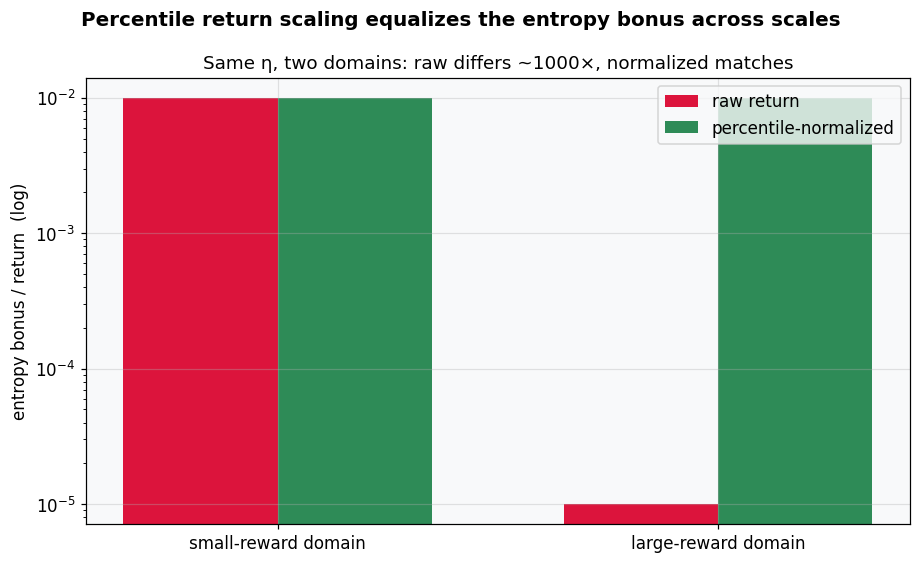

In [9]:
fig, ax = plt.subplots(figsize=(8.5, 5.2))
fig.suptitle('Percentile return scaling equalizes the entropy bonus across scales', fontsize=13, fontweight='bold')

names = [r[0] for r in rows]
raw = [r[1] for r in rows]
norm = [r[2] for r in rows]
x = np.arange(len(names)); w = 0.35
ax.bar(x - w/2, raw, w, color='crimson', label='raw return')
ax.bar(x + w/2, norm, w, color='seagreen', label='percentile-normalized')
ax.set_yscale('log')
ax.set_xticks(x); ax.set_xticklabels(names)
ax.set_ylabel('entropy bonus / return  (log)')
ax.set_title('Same η, two domains: raw differs ~1000×, normalized matches')
ax.legend()

plt.tight_layout()
plt.show()

### What you see

1. **What the plot shows:** With raw returns (red), the same entropy coefficient is ~1000× more influential in the small-reward domain than the large one. After percentile normalization (green), the relative entropy bonus is essentially equal across both domains.
2. **Why it looks this way:** Dividing returns by their 5–95 percentile range puts every domain's returns on a comparable scale, so a fixed η contributes the same proportion of exploration pressure regardless of raw reward magnitude.
3. **Key takeaway:** Return normalization decouples the exploration hyperparameter from reward scale, the last piece that lets one DreamerV3 configuration span hundreds of domains.


---
## Summary

| Experiment | Key insight |
|---|---|
| 1. Symlog | Compresses large magnitudes, stays linear near zero, invertible — one learning rate for all reward scales. |
| 2. Two-hot value | Cross-entropy over bins is scale-robust and distributional, unlike scale-sensitive MSE. |
| 3. Free bits | A KL floor removes pressure to compress below a threshold, preserving posterior information. |
| 4. Return normalization | Percentile scaling makes one entropy coefficient behave the same across reward scales. |

### Connection to the broader theory

DreamerV3 keeps the [DreamerV2](../research/02-dreamerv2.md) architecture but adds scale-invariant normalization so a single configuration masters 150+ domains. None of these tricks change the latent itself — they make learning *robust*, which is exactly what a plugin-first framework needs when loading unfamiliar models. The lineage next branches to **TD-MPC2**, which drops reconstruction for temporal-difference learning in latent, closer to value equivalence.